In [1]:
%pip install lazypredict 



   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [lazypredict]
   -------------------------- ------------- 2/3 [lazypredict]
   -------------------------- ------------- 2/3 [lazypredict]
   ---------------------------------------- 3/3 [lazypredict]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import lazypredict
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

In [20]:
import lazypredict
import sklearn

print("LazyPredict:", lazypredict.__version__)
print("Scikit-learn:", sklearn.__version__)

LazyPredict: 0.3.0
Scikit-learn: 1.9.0


In [2]:
df = pd.read_csv('BACE1_bioactivity data_pubchem_figerprints.csv')

In [3]:
X = df.drop('pIC50', axis = 1)
Y = df.pIC50

In [4]:
# Examine X dimension
X.shape

(7203, 881)

In [5]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
X.shape

(7203, 164)

In [6]:
# perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [8]:
# Compare ML algorithms
clf = LazyRegressor(verbose=1, ignore_warnings=True,custom_metric=None)
models_train, prediction_train = clf.fit(X_train, X_test, Y_train, Y_test)
model_test, prediction_test = clf.fit(X_train,X_test,Y_train,Y_test)

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

In [18]:
print(models_train.shape)
print(prediction_train.shape)

print(models_train.head())
print(prediction_train.head())

(41, 4)
(0, 0)
                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
HistGradientBoostingRegressor            0.534175   0.587227  0.953159   
RandomForestRegressor                    0.527329   0.581161  0.960138   
SVR                                      0.517272   0.572249  0.970299   
NuSVR                                    0.515923   0.571054  0.971654   
XGBRegressor                             0.500748   0.557607  0.986766   

                               Time Taken  
Model                                      
HistGradientBoostingRegressor    2.729408  
RandomForestRegressor           17.740159  
SVR                            106.268429  
NuSVR                           73.309053  
XGBRegressor                     0.550519  
Empty DataFrame
Columns: []
Index: []


In [31]:
print(models_train.shape)

(41, 4)


In [32]:
print(models_train.index.tolist())

['HistGradientBoostingRegressor', 'RandomForestRegressor', 'SVR', 'NuSVR', 'XGBRegressor', 'BaggingRegressor', 'KNeighborsRegressor', 'MLPRegressor', 'GradientBoostingRegressor', 'RidgeCV', 'ElasticNetCV', 'LassoCV', 'Ridge', 'BayesianRidge', 'TransformedTargetRegressor', 'LinearRegression', 'HuberRegressor', 'SGDRegressor', 'LinearSVR', 'PoissonRegressor', 'ExtraTreesRegressor', 'TweedieRegressor', 'GammaRegressor', 'OrthogonalMatchingPursuitCV', 'OrthogonalMatchingPursuit', 'ExtraTreeRegressor', 'LassoLarsCV', 'LassoLarsIC', 'DecisionTreeRegressor', 'AdaBoostRegressor', 'LarsCV', 'ElasticNet', 'DummyRegressor', 'LassoLars', 'Lasso', 'QuantileRegressor', 'PassiveAggressiveRegressor', 'GaussianProcessRegressor', 'KernelRidge', 'RANSACRegressor', 'Lars']


Data visualization of model performance

In [ ]:
import matplotlib.pyplot as plt

In [41]:
models_train.info()

<class 'pandas.DataFrame'>
Index: 41 entries, Lars to HistGradientBoostingRegressor
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Adjusted R-Squared  41 non-null     float64
 1   R-Squared           41 non-null     float64
 2   RMSE                41 non-null     float64
 3   Time Taken          41 non-null     float64
dtypes: float64(4)
memory usage: 1.6+ KB


In [ ]:
# Bar plot of R squared values

models = models_train.sort_values(by="R-Squared")

plt.figure(figsize=(10, 12))

plt.barh(
    y=models.index,
    width=models["R-Squared"]
)

plt.xlabel("R-Squared")
plt.ylabel("Models")

plt.tight_layout()
plt.show()

In [45]:
print(models['R-Squared'].describe())

count    4.100000e+01
mean    -1.210287e+06
std      7.749610e+06
min     -4.962172e+07
25%      2.740167e-01
50%      3.560589e-01
75%      4.281991e-01
max      5.872275e-01
Name: R-Squared, dtype: float64


In [46]:
print(models)

                               Adjusted R-Squared     R-Squared          RMSE  \
Model                                                                           
Lars                                -5.599943e+07 -4.962172e+07  10450.715990   
RANSACRegressor                     -2.402666e+01 -2.117640e+01      6.986435   
KernelRidge                         -2.354044e+01 -2.074555e+01      6.918236   
GaussianProcessRegressor            -1.255630e+01 -1.101238e+01      5.141913   
PassiveAggressiveRegressor          -2.689370e-01 -1.244192e-01      1.573165   
QuantileRegressor                   -1.686971e-01 -3.559547e-02      1.509751   
Lasso                               -1.288840e-01 -3.166649e-04      1.483812   
DummyRegressor                      -1.288840e-01 -3.166649e-04      1.483812   
LassoLars                           -1.288840e-01 -3.166649e-04      1.483812   
ElasticNet                          -1.146408e-01  1.230442e-02      1.474422   
LarsCV                      

In [47]:
print(models.isna().sum())

Adjusted R-Squared    0
R-Squared             0
RMSE                  0
Time Taken            0
dtype: int64


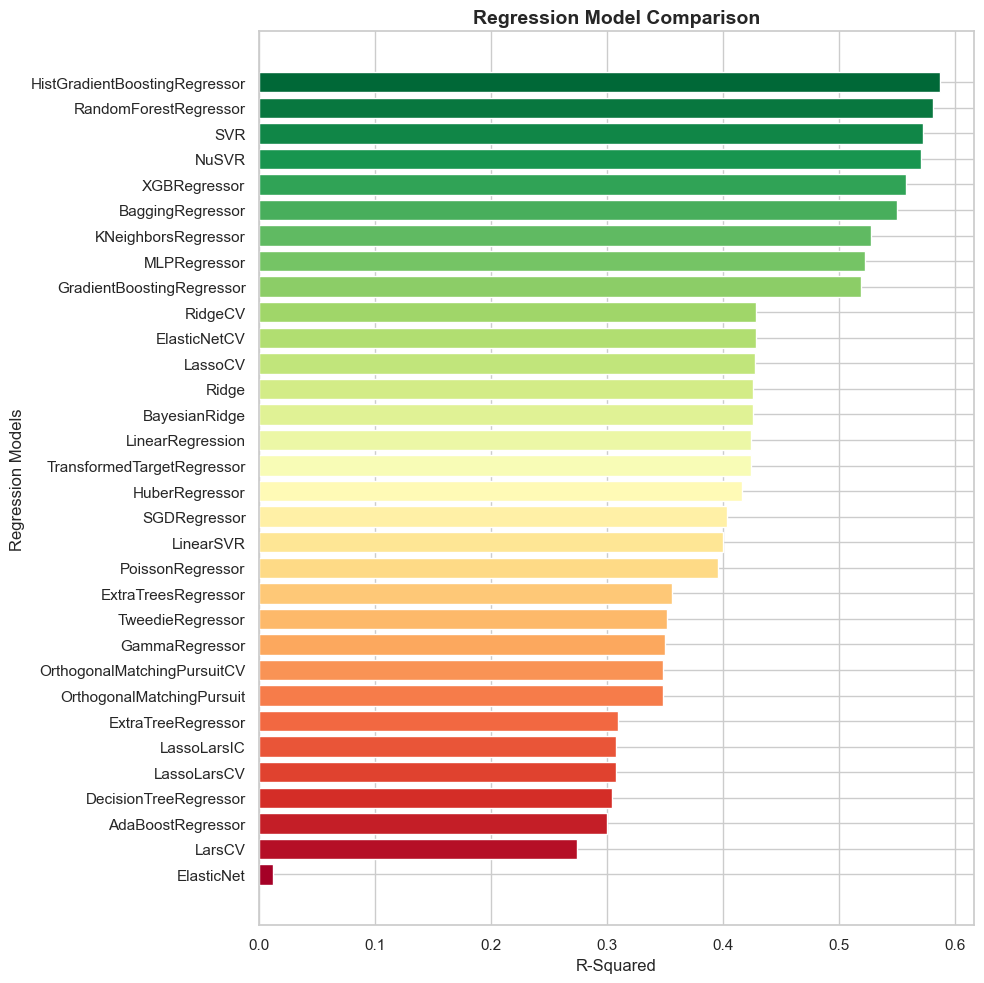

In [64]:
import numpy as np

# Remove extreme outliers for visualization
models_plot = models_train[models_train["R-Squared"] > 0]
models_plot = models_plot.sort_values(by="R-Squared")

# Create gradient colors
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(models_plot)))
plt.figure(figsize=(10,10))

plt.barh(
    models_plot.index,
    models_plot["R-Squared"],
    color=colors
)

plt.xlabel("R-Squared", fontsize=12)
plt.ylabel("Regression Models", fontsize=12)
plt.title("Regression Model Comparison", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

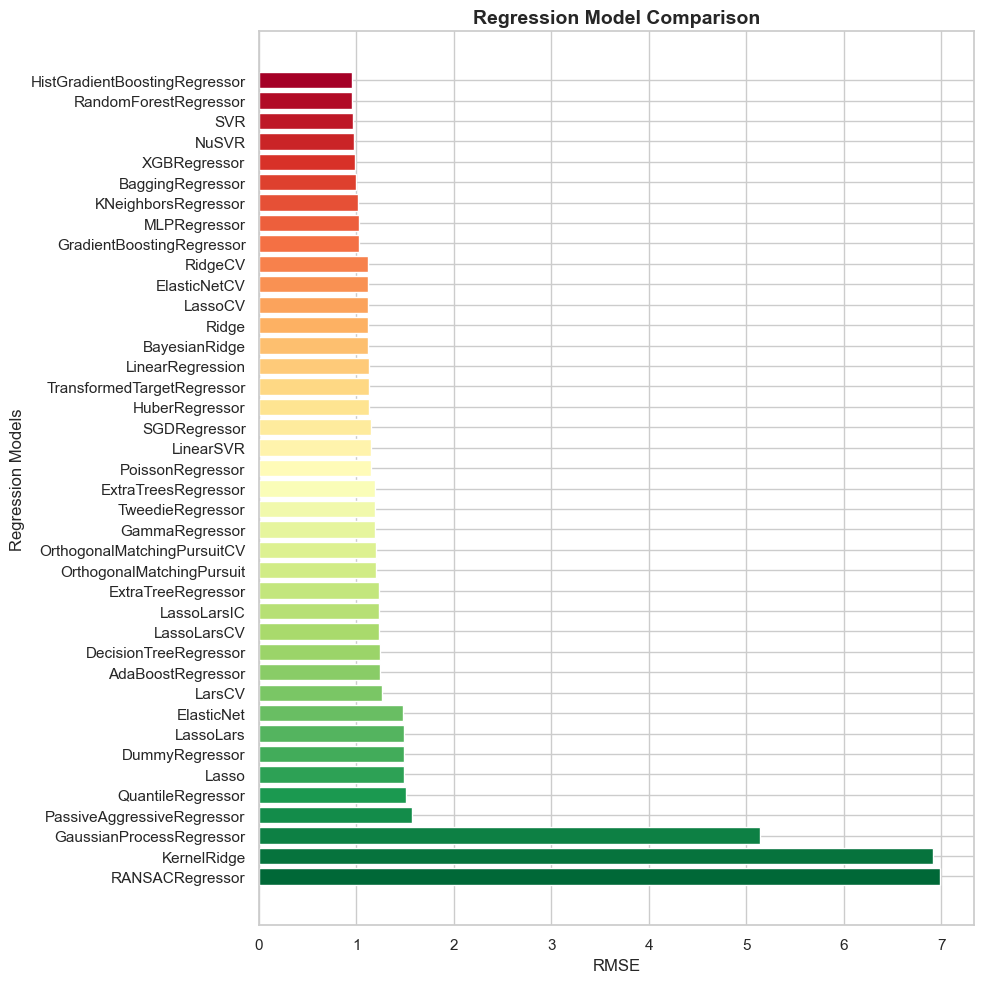

In [ ]:
# Remove extreme outliers for visualization
models_plot = models_train[models_train["RMSE"] < 1000]
models_plot = models_plot.sort_values(by="RMSE", ascending=False)

# Create gradient colors
colors = plt.cm.RdYlGn(np.linspace(1, 0, len(models_plot)))
plt.figure(figsize=(10,10))

plt.barh(
    models_plot.index,
    models_plot["RMSE"],
    color=colors
)

plt.xlabel("RMSE", fontsize=12)
plt.ylabel("Regression Models", fontsize=12)
plt.title("Regression Model Comparison", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

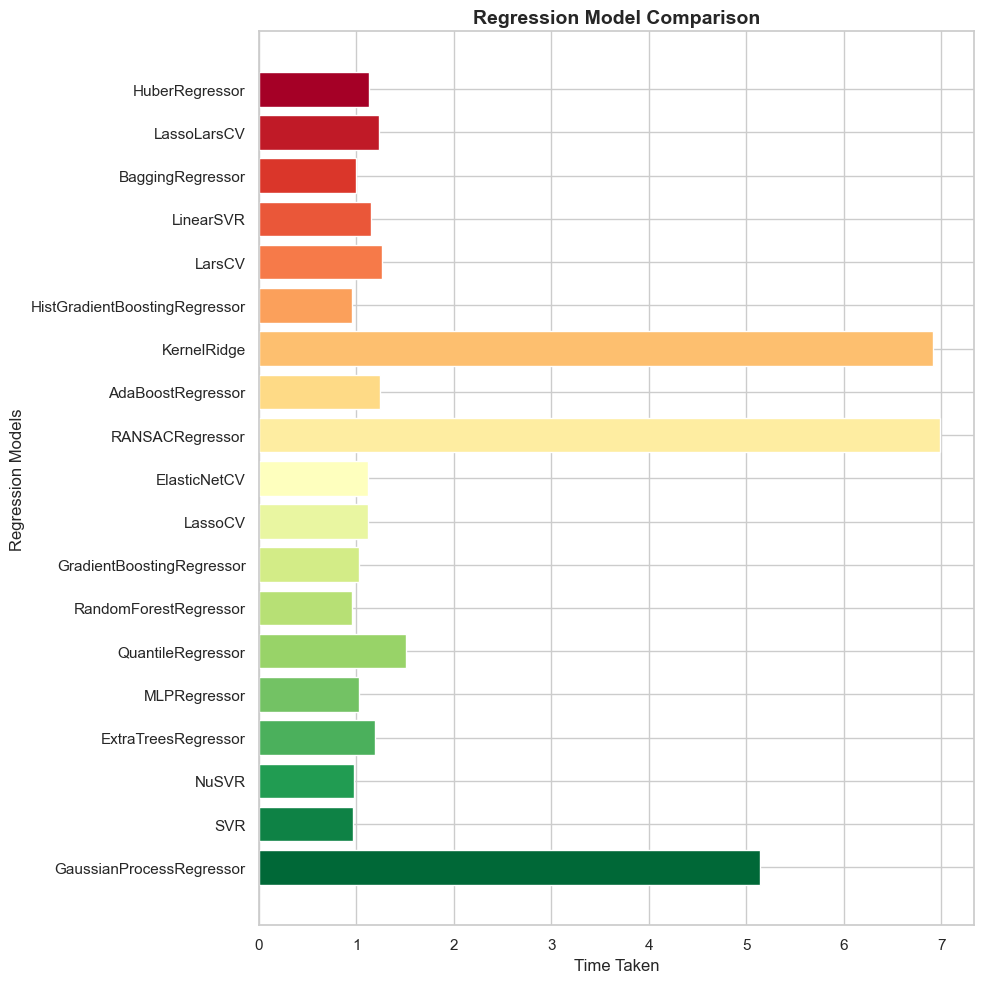

In [79]:
# Bar plot of calculation time
# Remove extreme outliers for visualization
models_plot = models_train[models_train["Time Taken"] > 1]
models_plot = models_plot.sort_values(by="Time Taken", ascending=False)

# Create gradient colors
colors = plt.cm.RdYlGn(np.linspace(1, 0, len(models_plot)))
plt.figure(figsize=(10,10))

plt.barh(
    models_plot.index,
    models_plot["RMSE"],
    color=colors
)

plt.xlabel("Time Taken", fontsize=12)
plt.ylabel("Regression Models", fontsize=12)
plt.title("Regression Model Comparison", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()